In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import warnings
from scipy import signal
from scipy.signal import detrend
from scipy.stats import t
from scipy.stats import pearsonr
import xarray as xr
import os
from glob import glob
import geopandas as gpd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [2]:
##玉米
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/作物数据/maize/GDHY_maize/maize_second/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = glob(os.path.join(folder_path, '*.nc4'))
# 按文件名中的年份进行排序（假设文件名后四位代表年份）
files.sort(key=lambda f: int(os.path.basename(f)[-8:-4]))
# 用来存储所有读取的 Dataset 对象
datasets = []
# 遍历每个文件
for file in files:
    # 读取当前的 nc 文件
    ds = xr.open_dataset(file)
    # 提取文件名的后四位作为时间
    time_value = int(os.path.basename(file)[-8:-4])  # 假设文件名最后四位是年份
    # 给这个 Dataset 添加一个新的 'time' 维度
    ds = ds.assign_coords(time=[time_value])
    # 将 Dataset 添加到列表中
    datasets.append(ds)
# 使用 concat 将所有文件合并
maize = xr.concat(datasets, dim='time')
maize = maize['var']
maize 

<xarray.DataArray 'var' (time: 36, lat: 360, lon: 720)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.25 0.75 1.25 1.75 2.25 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) int64 1981 1982 1983 1984 1985 ... 2012 2013 2014 2015 2016

In [3]:
def trans_lon(ds):
    lon_name = 'lon'  #你的nc文件中经度的命名
    ds['longitude_adjusted'] = xr.where(
        ds[lon_name] > 180,
        ds[lon_name] - 360,
        ds[lon_name])
    ds = (
        ds
        .swap_dims({lon_name: 'longitude_adjusted'})
        .sel(**{'longitude_adjusted': sorted(ds.longitude_adjusted)})
        .drop(lon_name))
    ds = ds.rename({'longitude_adjusted': lon_name})
    return ds
crop_name=['maize']
for i in crop_name:
    locals()[f'{i}']=trans_lon(locals()[f'{i}'])

In [4]:

## 时间切片
def time_sel(data, yearbegin, yearend):
    data = data.sel(time=slice(f'{yearbegin}-01-01', f'{yearend}-12-31'))
    return data

## 去季节循环 + 去线性趋势
def detrend_weather(data):
    lon = data['lon']
    lat = data['lat']
    time = data['time']

    data_np = data.values.reshape((12, int(len(data) / 12), len(lat), len(lon)), order='F').transpose((1, 0, 2, 3))
    data_season = np.mean(data_np, axis=0)
    data_diff = data_np - data_season
    data_diff = data_diff.transpose((1, 0, 2, 3)).reshape((len(time), len(lat), len(lon)), order='F')

    # 这里建议用 data_diff 本身来做 mask，更安全
    data_diff = np.ma.masked_array(data_diff, mask=np.isnan(data_diff))
    data_diff = xr.DataArray(data_diff, coords=[time, lat, lon], dims=['time', 'lat', 'lon'])

    data_detrend = signal.detrend(data_diff.fillna(0), axis=0, type='linear', bp=0)
    data_detrend = xr.DataArray(data_detrend, coords=[time, lat, lon], dims=['time', 'lat', 'lon'])

    return data_detrend

In [5]:
## 读取 ERA5-Land soil moisture
ds = xr.open_dataset('/Volumes/limenghan/ERA5/soil_moisture/era5_monthly_swvl2_swvl3_1950_2024.nc')
ds

<xarray.Dataset>
Dimensions:     (valid_time: 912, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 1949-01-01 1949-02-01 ... 2024-12-01
  * latitude    (latitude) float64 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      (valid_time) <U4 ...
Data variables:
    swvl2       (valid_time, latitude, longitude) float32 ...
    swvl3       (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-12T10:26 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:

## 读取 ERA5-Land soil moisture
ds = xr.open_dataset('/Volumes/limenghan/ERA5/soil_moisture/era5_monthly_swvl2_swvl3_1950_2024.nc')

# 坐标改名
rename_dict = {}
if 'longitude' in ds.coords:
    rename_dict['longitude'] = 'lon'
if 'latitude' in ds.coords:
    rename_dict['latitude'] = 'lat'
if 'valid_time' in ds.coords:
    rename_dict['valid_time'] = 'time'
if rename_dict:
    ds = ds.rename(rename_dict)

# 先时间切片
ds = ds.sel(time=slice('1980-01-01', '2020-12-31'))

# 如果经度是 0~360，转成 -180~180
if ds.lon.max() > 180:
    ds = ds.assign_coords(lon=((ds.lon + 180) % 360) - 180).sortby('lon')

# 先转成 float32，减少内存
ds = ds.astype('float32')

# =========================================================
# 方法1：如果原始分辨率是规则高分辨率网格，直接 coarsen 到 0.5°
# =========================================================
# 例如 ERA5-Land 常见是 0.1°，那么 5×5 平均后就是 0.5°
dlat = float(ds.lat.diff('lat').mean())
dlon = float(ds.lon.diff('lon').mean())

print('original resolution:', dlat, dlon)

lat_factor = int(round(0.5 / abs(dlat)))
lon_factor = int(round(0.5 / abs(dlon)))

ds_05 = ds.coarsen(lat=lat_factor, lon=lon_factor, boundary='trim').mean()

original resolution: -0.25 0.25


In [7]:

# =========================================================
# 如果你更想严格定义 0.5° 网格中心，也可以再 assign 一下坐标
# 一般 coarsen 后直接用也可以
# =========================================================

# 裁剪巴西区域
ds_05_bra = ds_05.sel(lon=slice(-75, -34), lat=slice(6, -40))

## 提取第2、3层
sm2 = ds_05_bra['swvl2']
sm3 = ds_05_bra['swvl3']

## 厚度加权平均，得到根区土壤湿度
thk2 = 0.21
thk3 = 0.72
smroot = (sm2 * thk2 + sm3 * thk3) / (thk2 + thk3)
smroot.name = 'smroot'
smroot.attrs['long_name'] = 'Root-zone soil moisture from ERA5-Land layer 2 and 3'
smroot.attrs['units'] = 'm3 m-3'
smroot.attrs['depth'] = '0.07-1.00 m'
smroot.attrs['resolution'] = '0.5 degree'

# 去趋势
smroot = detrend_weather(smroot)
smroot_bra=smroot
smroot_bra

<xarray.DataArray (time: 492, lat: 92, lon: 82)>
array([[[-5.2823439e-02, -4.8655778e-02, -1.9894857e-02, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [-2.5763322e-02, -2.7303526e-02, -5.0556753e-03, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [-5.6235697e-03, -9.2866868e-03,  7.5409643e-02, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        ...,
        [ 2.4565993e-06,  2.4565993e-06,  9.7579393e-04, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [ 2.4565993e-06,  2.4565993e-06,  2.4565993e-06, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06],
        [ 2.4565993e-06,  2.4565993e-06,  2.4565993e-06, ...,
          2.4565993e-06,  2.4565993e-06,  2.4565993e-06]],

       [[-3.8235877e-02, -3.8226590e-02, -3.1170802e-02, ...,
         -8.7405933e-06, -8.7405933e-06, -8.7405933e-06],
        [-2.4408042e-02, -2.8699890e-02,  3.7283972e-03, ...,
         -8.7405933e-06, -8.7405933e-06, -8.7405933e-06],
        [-8.4615834e-03, -3.1353533e-03,  6.7007467e-02, ...,
         -8.7405933e-06, -8.7405933e-06, -8.7405933e-06],
...
        [-1.2040152e-06, -1.2040152e-06, -1.2758460e-03, ...,
         -1.2040152e-06, -1.2040152e-06, -1.2040152e-06],
        [-1.2040152e-06, -1.2040152e-06, -1.2040152e-06, ...,
         -1.2040152e-06, -1.2040152e-06, -1.2040152e-06],
        [-1.2040152e-06, -1.2040152e-06, -1.2040152e-06, ...,
         -1.2040152e-06, -1.2040152e-06, -1.2040152e-06]],

       [[-2.4386868e-03, -1.4103893e-02,  1.0852376e-02, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [-4.6318401e-02,  2.0710785e-02,  2.4517652e-02, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [-6.5433264e-02,  1.3740960e-02,  1.7148919e-02, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        ...,
        [ 1.7110054e-06,  1.7110054e-06, -1.4503738e-03, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [ 1.7110054e-06,  1.7110054e-06,  1.7110054e-06, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06],
        [ 1.7110054e-06,  1.7110054e-06,  1.7110054e-06, ...,
          1.7110054e-06,  1.7110054e-06,  1.7110054e-06]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2020-12-01
  * lat      (lat) float64 5.875 5.375 4.875 4.375 ... -38.62 -39.12 -39.62
  * lon      (lon) float64 -74.88 -74.38 -73.88 -73.38 ... -35.38 -34.88 -34.38

In [8]:
##tmx
tmx=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.tmx.dat.nc')
tmx=tmx['tmx']
tmx=time_sel(tmx,1980,2020)
tmx=detrend_weather(tmx)
tmx=time_sel(tmx,1980,2020)
if tmx.lon.max()>180:
    tmx=trans_lon(tmx)
tmx_bra=tmx.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [9]:
##tmp
tmp=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.tmp.dat.nc')
tmp=tmp['tmp']
tmp=time_sel(tmp,1980,2020)
tmp=detrend_weather(tmp)
tmp=time_sel(tmp,1980,2020)
if tmp.lon.max()>180:
    tmp=trans_lon(tmp)
tmp_bra=tmp.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [10]:
##pre
pre=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.04.1901.2019.pre.dat.nc')
pre=pre['pre']
pre=time_sel(pre,1980,2020)
pre=detrend_weather(pre)
pre=time_sel(pre,1980,2020)
if pre.lon.max()>180:
    pre=trans_lon(pre)
pre_bra=pre.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [11]:
#flux
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/气象要素/flux/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
flux= xr.open_mfdataset(files, combine='nested', concat_dim='time')
flux= flux.rename({'longitude': 'lon'})
flux= flux.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(flux.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(flux.lat)/360), int(len(flux.lon)/720)  # 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    flux=flux.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
msdwswrf=flux['msdwswrf']
##时间切片
msdwswrf=time_sel(msdwswrf,1980,2020)
msdwswrf=detrend_weather(msdwswrf)
if msdwswrf.lon.max()>180:
    msdwswrf=trans_lon(msdwswrf)
msdwswrf_bra=msdwswrf.sel(lon=slice(-75,-34), lat=slice(6,-40))

In [12]:
#evap
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/气象要素/evap/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = folder_path + '*.nc'
# 使用 open_mfdataset 函数来打开所有匹配的文件，并将它们合并成一个 Dataset
evap= xr.open_mfdataset(files, combine='nested', concat_dim='time')
evap= evap.rename({'longitude': 'lon'})
evap= evap.rename({'latitude': 'lat'})
# 使用 coarsen 进行降采样
if len(evap.lon)>180:
    # 定义经度和纬度的降采样因子
    lon_factor, lat_factor = int(len(evap.lat)/360), int(len(evap.lon)/720)  # 对应的降采样因子
    # 使用 coarsen 方法进行降采样
    evap= evap.coarsen(lon=lon_factor, lat=lat_factor, boundary="trim").mean()
evap=evap['e']
##时间切片
evap=time_sel(evap,1980,2020)
evap=detrend_weather(evap)
evap=time_sel(evap,1980,2020)
if evap.lon.max()>180:
    evap=trans_lon(evap)
evap_bra=evap.sel(lon=slice(-75,-34), lat=slice(6,-40))

In [13]:
##vap
vap=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.vap.dat.nc')
vap=vap['vap']
vap=time_sel(vap,1980,2020)
vap=detrend_weather(vap)
vap=time_sel(vap,1980,2020)
if vap.lon.max()>180:
    vap=trans_lon(vap)
vap_bra=vap.sel(lon=slice(-75,-34), lat=slice(-34,6))
# 将值为 0 的点 mask 掉，设为 NaN
tmp_bra = tmp_bra.where(tmp_bra!= 0, np.nan)
vap_bra = vap_bra.where(vap_bra!= 0, np.nan)
##vpd
e0 = 6.108 *np.exp(17.27 * tmp / (tmp + 237.3))
vpd=e0-vap
vpd_bra=vpd.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [14]:
##wet
wet=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.wet.dat.nc')
wet=wet['wet']
wet=time_sel(wet,1980,2020)
wet=detrend_weather(wet)
wet=time_sel(wet,1980,2020)
if wet.lon.max()>180:
    wet=trans_lon(wet)
wet_bra=wet.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [15]:
##cloud
cld=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.04.1901.2019.cld.dat.nc')
cld=cld['cld']                                                                                                                                                                                       
cld=time_sel(cld,1980,2020)
cld=detrend_weather(cld)
cld=time_sel(cld,1980,2020)
if cld.lon.max()>180:
    cld=trans_lon(cld)
cld_bra=cld.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [16]:
##dtr
dtr=xr.open_dataset('/Volumes/limenghan/气象要素/cru_ts4.07.1901.2022.dtr.dat.nc')
dtr=dtr['dtr']
dtr=time_sel(dtr,1980,2020)
dtr=detrend_weather(dtr)
dtr=time_sel(dtr,1980,2020)
if dtr.lon.max()>180:
    dtr=trans_lon(dtr)
dtr_bra=dtr.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [17]:
variable_list=['dtr','cld','wet','tmp','tmx','pre','vpd','evap','msdwswrf','smroot','vap']
for i in variable_list:
    locals()[f'{i}_bra_sort']=locals()[f'{i}_bra'].sortby(['lat', 'lon'])

In [18]:
##全球地图
def capitalize_words(s):
    # 检查元素是否是字符串，如果是，就进行首字母大写操作，如果不是，返回原始值
    if isinstance(s, str):
        return ' '.join(word.capitalize() for word in s.split())
    else:
        return s

Brazil = gpd.read_file("/Users/limenghan/Desktop/地图/次国家/gadm41_BRA_shp/gadm41_BRA_1.shp")
Brazil.rename(columns={'NAME_1': 'loc'}, inplace=True)
BRA_shp = gpd.read_file("/Volumes/limenghan/地图/gadm41_BRA_shp/gadm41_BRA_0.shp")
BRA_shp.rename(columns={'NAME_1': 'loc'}, inplace=True)

In [19]:
##处理大豆单产数据
def calculate_5yr_mean(dataarray):
    """
    对 DataArray 的时间维度进行五年滑动平均。
    :param dataarray: xarray.DataArray，包含 time, lon, lat 维度
    :return: 五年滑动平均的 DataArray
    """
    # 计算五年滑动平均（时间维度假定为 'time'）
    rolling_mean = dataarray.rolling(time=5, center=True).mean()
    return rolling_mean

def calculate_anomaly_percentage(dataarray):
    """
    计算 DataArray 每个格点的异常百分比。
    :param dataarray: xarray.DataArray，包含 time, lon, lat 维度
    :return: 异常百分比的 DataArray
    """
    # 计算五年滑动平均
    trend = calculate_5yr_mean(dataarray)
    
    # 避免趋势值为 0 的问题
    trend = trend.where(trend != 0, np.nan)  # 将趋势值为 0 的位置设为 NaN
    
    # 计算异常百分比 = ((实际值 - 趋势值) / 趋势值) * 100
    anomalies = ((dataarray - trend) / trend) * 100
    
    return anomalies
maize_ano=calculate_anomaly_percentage(maize)

In [20]:
import numpy as np
import xarray as xr
from shapely.geometry import Point
from shapely.prepared import prep

def mask_outside_geodf(dataarray: xr.DataArray, geodf):
    """
    将 geodf 区域外的格点置为 NaN（区域内保留）。
    适用于规则网格：lat/lon 为 1D 坐标。
    自动处理 lon=0..360 与 lon=-180..180 的不一致。
    """

    da = dataarray

    # ---- 1) 经度体系对齐：如果 da.lon 是 0..360 而 shapefile 用 -180..180，则转换 ----
    if "lon" in da.coords:
        lon = da["lon"].values
        # 判断 lon 是否是 0..360
        if np.nanmin(lon) >= 0 and np.nanmax(lon) > 180:
            da = da.assign_coords(lon=(((da["lon"] + 180) % 360) - 180)).sortby("lon")

    # ---- 2) 构建掩膜（lat/lon 1D）----
    lons = da["lon"].values
    lats = da["lat"].values
    lon2d, lat2d = np.meshgrid(lons, lats)

    region = prep(geodf.geometry.unary_union)

    # covers 比 contains 更适合栅格点（边界也算内）
    flat_points = [Point(xy) for xy in zip(lon2d.ravel(), lat2d.ravel())]
    mask = np.array([region.covers(p) for p in flat_points], dtype=bool).reshape(lat2d.shape)

    mask_da = xr.DataArray(mask, coords={"lat": da["lat"], "lon": da["lon"]}, dims=("lat", "lon"))

    # ---- 3) 应用掩膜：区域外 -> NaN ----
    return da.where(mask_da)


#裁剪 DataArray
maize_yield_bra= mask_outside_geodf(maize, BRA_shp)
maize_ano_bra= mask_outside_geodf(maize_ano,BRA_shp)



In [21]:
maize_ano_bra=maize_ano_bra.sel(lon=slice(-75,-34), lat=slice(-40,6))

In [22]:
target_lat = maize_ano_bra.lat
target_lon = maize_ano_bra.lon
met_interp = {}
for v in variable_list:
    da = locals()[f"{v}_bra_sort"]  # 你已经sort好的
    # 如果还没 sort，可用：da = locals()[f"{v}_{area}"].sortby(["lat","lon"])
    met_interp[v] = da.interp(lat=target_lat, lon=target_lon, method="linear")

In [23]:
variable_list=['tmp', 'tmx', 'pre', 'smroot', 'vpd', 'msdwswrf', 'cld', 'dtr']

In [24]:
def seasonal_mean_by_year(da: xr.DataArray, months):
    """把月数据按year聚合成季节均值（JFM/MAM 这种不跨年的季节最稳）"""
    da_sel = da.where(da["time"].dt.month.isin(months), drop=True)
    return da_sel.groupby("time.year").mean("time")

# 气象季节量（year, lat, lon）
met_JFM = {v: seasonal_mean_by_year(met_interp[v], [1,2,3]) for v in variable_list}
met_MAM = {v: seasonal_mean_by_year(met_interp[v], [3,4,5]) for v in variable_list}

# 单产异常：转换成 year 维
# 兼容 maize_ano_bra.time 为 datetime 或者本来就是 year
if "time" in maize_ano_bra.dims:
    y = maize_ano_bra.copy()
    if np.issubdtype(y["time"].dtype, np.datetime64):
        y = y.groupby("time.year").mean("time")
    else:
        # 如果 time 本身就是 year 数值
        y = y.rename({"time":"year"})
else:
    y = maize_ano_bra

y = y.rename({"year":"year"})  # 保底


In [25]:
# 气象季节量（year, lat, lon）
met_AMJ = {v: seasonal_mean_by_year(met_interp[v], [4,5,6]) for v in variable_list}

In [26]:
def area_weighted_mean_abs_corr(x_by_year, y_by_year):
    """
    x_by_year, y_by_year: (year, lat, lon)
    输出：一个数（巴西区域加权后的 mean(|corr|)）
    """
    x_al, y_al = xr.align(x_by_year, y_by_year, join="inner")
    r = xr.corr(x_al, y_al, dim="year")  # (lat, lon)

    # 权重：cos(lat)
    w = np.cos(np.deg2rad(r["lat"]))
    score = np.abs(r).weighted(w).mean(("lat","lon"), skipna=True)
    return score.item(), r  # 返回分数 + 空间r场（可选）

def rank_variables(met_season: dict, y_by_year: xr.DataArray):
    scores = {}
    r_maps = {}
    for v, x in met_season.items():
        s, rmap = area_weighted_mean_abs_corr(x, y_by_year)
        scores[v] = s
        r_maps[v] = rmap
    ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    return ranked, scores, r_maps

rank_JFM, scores_JFM, rmap_JFM = rank_variables(met_JFM, y)
rank_AMJ, scores_AMJ, rmap_AMJ = rank_variables(met_AMJ, y)
print("JFM 相关强度排名（mean |corr|）Top10:")
print(rank_JFM[:10])
print("\nAMJ 相关强度排名（mean |corr|）Top10:")
print(rank_AMJ[:10])


JFM 相关强度排名（mean |corr|）Top10:
[('msdwswrf', 0.24469146974897651), ('vpd', 0.23857711365547668), ('dtr', 0.2146568710525661), ('smroot', 0.2026610334141549), ('pre', 0.20080013786837037), ('tmx', 0.14183242777770544), ('cld', 0.13564854081635486), ('tmp', 0.11285117049868622)]

MAM 相关强度排名（mean |corr|）Top10:
[('msdwswrf', 0.2563068464513907), ('dtr', 0.24011594216410545), ('pre', 0.20823624123145834), ('smroot', 0.1699158072878248), ('vpd', 0.16708235857630055), ('tmx', 0.1448596446043959), ('tmp', 0.1268973579287563), ('cld', 0.12521688923362428)]

AMJ 相关强度排名（mean |corr|）Top10:
[('dtr', 0.2245578204800015), ('msdwswrf', 0.16923893004445253), ('pre', 0.16458814525006968), ('smroot', 0.1560935469475541), ('tmp', 0.15394787707014204), ('vpd', 0.13338710386715238), ('cld', 0.12795624775469014), ('tmx', 0.11521824393764615)]


In [27]:
import numpy as np
import xarray as xr
from sklearn.linear_model import RidgeCV
from scipy import stats

# ============================================================
# 0) 强制统一分析期：把 X 裁剪到 y 的年份（你之前是1981–2016）
# ============================================================
years_y = y["year"]
met_JFM = {v: met_JFM[v].sel(year=years_y) for v in variable_list}
met_MAM = {v: met_MAM[v].sel(year=years_y) for v in variable_list}
y = y.sel(year=years_y)

# ============================================================
# 1) 标准化与构造 X(year,var,lat,lon)
# ============================================================

def zscore_over_year(da: xr.DataArray) -> xr.DataArray:
    mu = da.mean("year")
    sd = da.std("year")
    return (da - mu) / sd.where(sd != 0)

def build_X(met_season: dict, var_list: list) -> xr.DataArray:
    """
    关键修复：强制输出 X 的维度顺序为 (year, var, lat, lon)
    """
    X = xr.concat([zscore_over_year(met_season[v]) for v in var_list], dim="var")
    X = X.assign_coords(var=var_list)

    # ✅ 强制维度顺序
    need = ["year", "var", "lat", "lon"]
    missing = [d for d in need if d not in X.dims]
    if missing:
        raise ValueError(f"build_X 得到的X缺少维度 {missing}，当前dims={X.dims}")

    X = X.transpose("year", "var", "lat", "lon")
    return X

def choose_alpha_by_area_mean(y_da: xr.DataArray, X_da: xr.DataArray, alphas=None) -> float:
    """
    关键修复：区域平均后强制变成 (year, var) 再喂给 RidgeCV
    """
    if alphas is None:
        alphas = np.logspace(-3, 3, 25)

    y_al, X_al = xr.align(y_da, X_da, join="inner")

    w = np.cos(np.deg2rad(y_al["lat"]))

    y1 = y_al.weighted(w).mean(("lat", "lon"), skipna=True)  # (year,)
    X1 = X_al.weighted(w).mean(("lat", "lon"), skipna=True)  # (year,var) 或 (var,year)

    # ✅ 强制 (year, var)
    if set(X1.dims) == {"year", "var"}:
        X1 = X1.transpose("year", "var")
    else:
        raise ValueError(f"X1 维度异常：{X1.dims}，期望包含 year 与 var")

    y1v = y1.values
    X1v = X1.values  # (nyear, nvar)

    m = np.isfinite(y1v) & np.all(np.isfinite(X1v), axis=1)
    y1v, X1v = y1v[m], X1v[m]

    if y1v.size < 10:
        raise ValueError(f"有效年份太少（{y1v.size}），无法稳定选择 alpha。")

    model = RidgeCV(alphas=alphas, fit_intercept=True)
    model.fit(X1v, y1v)
    return float(model.alpha_)

# ============================================================
# 3) Ridge：逐像元闭式解得到 beta(var,lat,lon)
# ============================================================
def ridge_beta_map(y_da: xr.DataArray, X_da: xr.DataArray, alpha: float) -> xr.DataArray:
    y_al, X_al = xr.align(y_da, X_da, join="inner")
    yz = zscore_over_year(y_al)  # y也标准化，让系数可比

    def _ridge_1pix(y_vec, X_mat, alpha):
        ok = np.isfinite(y_vec) & np.all(np.isfinite(X_mat), axis=1)
        if ok.sum() < X_mat.shape[1] + 6:
            return np.full((X_mat.shape[1],), np.nan)

        yy = y_vec[ok]
        XX = X_mat[ok, :]
        p = XX.shape[1]

        A = XX.T @ XX + alpha * np.eye(p)
        b = XX.T @ yy
        try:
            beta = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            beta = np.full((p,), np.nan)
        return beta

    beta = xr.apply_ufunc(
        _ridge_1pix,
        yz,
        X_al,
        xr.DataArray(alpha),
        input_core_dims=[["year"], ["year", "var"], []],
        output_core_dims=[["var"]],
        vectorize=True,
        dask="allowed",
        output_dtypes=[float],
    ).transpose("var", "lat", "lon")

    return beta.assign_coords(var=X_al["var"])

def beta_importance(beta: xr.DataArray) -> xr.DataArray:
    w = np.cos(np.deg2rad(beta["lat"]))
    return np.abs(beta).weighted(w).mean(("lat", "lon"), skipna=True)

def ridge_select_top(met_season, y_da, var_list, topN=4, alphas=None, alpha=None):
    X_all = build_X(met_season, var_list)
    y_al, X_all = xr.align(y_da, X_all, join="inner")

    if alpha is None:
        alpha = choose_alpha_by_area_mean(y_al, X_all, alphas=alphas)

    beta_all = ridge_beta_map(y_al, X_all, alpha=alpha)
    imp_all = beta_importance(beta_all)
    ranked = imp_all.sortby(imp_all, ascending=False)
    top_vars = ranked["var"].values[:topN].tolist()
    return top_vars, alpha, imp_all, beta_all

# ============================================================
# 4) 多元 OLS：对 TopN 变量做验证（beta + p + R2）
# ============================================================
def ols_beta_p_maps(y_da: xr.DataArray, X_da: xr.DataArray):
    y_al, X_al = xr.align(y_da, X_da, join="inner")
    yz = zscore_over_year(y_al)  # 让系数可比

    def _ols_1pix(y_vec, X_mat):
        ok = np.isfinite(y_vec) & np.all(np.isfinite(X_mat), axis=1)
        if ok.sum() < X_mat.shape[1] + 6:
            p = X_mat.shape[1]
            return (np.full((p,), np.nan), np.full((p,), np.nan), np.nan)

        yy = y_vec[ok]
        XX = X_mat[ok, :]
        n, p = XX.shape

        A = np.column_stack([np.ones(n), XX])  # intercept + X

        try:
            coef, _, _, _ = np.linalg.lstsq(A, yy, rcond=None)
        except np.linalg.LinAlgError:
            return (np.full((p,), np.nan), np.full((p,), np.nan), np.nan)

        yhat = A @ coef
        resid = yy - yhat
        dof = n - (p + 1)
        if dof <= 3:
            return (np.full((p,), np.nan), np.full((p,), np.nan), np.nan)

        s2 = (resid @ resid) / dof
        try:
            cov = s2 * np.linalg.inv(A.T @ A)
        except np.linalg.LinAlgError:
            return (np.full((p,), np.nan), np.full((p,), np.nan), np.nan)

        beta = coef[1:]
        se = np.sqrt(np.diag(cov))[1:]
        tstat = beta / se
        pval = 2 * stats.t.sf(np.abs(tstat), df=dof)

        ss_tot = np.sum((yy - yy.mean())**2)
        ss_res = np.sum(resid**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        return beta, pval, r2

    out = xr.apply_ufunc(
        _ols_1pix,
        yz,
        X_al,
        input_core_dims=[["year"], ["year", "var"]],
        output_core_dims=[["var"], ["var"], []],
        vectorize=True,
        dask="allowed",
        output_dtypes=[float, float, float],
    )

    beta = out[0].transpose("var", "lat", "lon").assign_coords(var=X_al["var"])
    pval = out[1].transpose("var", "lat", "lon").assign_coords(var=X_al["var"])
    r2   = out[2].transpose("lat", "lon")
    return beta, pval, r2

# ============================================================
# 5) Ridge bootstrap：CI、显著性、同号比例、bootstrap p值
# ============================================================
def bootstrap_ridge_beta(y_da: xr.DataArray, X_da: xr.DataArray, alpha: float, nboot=300, seed=0):
    y_al, X_al = xr.align(y_da, X_da, join="inner")
    n = y_al.sizes["year"]
    rng = np.random.default_rng(seed)

    betas = []
    for b in range(nboot):
        idx = rng.integers(0, n, size=n)      # 用索引抽样最稳
        yb = y_al.isel(year=idx)
        Xb = X_al.isel(year=idx)
        betas.append(ridge_beta_map(yb, Xb, alpha=alpha))

    return xr.concat(betas, dim="boot").assign_coords(boot=np.arange(nboot))

def summarize_bootstrap(beta_boot: xr.DataArray, beta_ref: xr.DataArray):
    """
    beta_boot: (boot,var,lat,lon)
    beta_ref : (var,lat,lon)
    输出：
      beta_mean, beta_std (var,lat,lon)
      ci_low, ci_high     (var,lat,lon) 95% CI
      sig_ci              (var,lat,lon)  CI不跨0
      sign_agree          (var,lat,lon)  与参考同号比例
      p_boot              (var,lat,lon)  bootstrap双侧p（近似）
    """
    beta_mean = beta_boot.mean("boot")
    beta_std  = beta_boot.std("boot")

    q = beta_boot.quantile([0.025, 0.975], dim="boot")
    ci_low  = q.sel(quantile=0.025).drop_vars("quantile")
    ci_high = q.sel(quantile=0.975).drop_vars("quantile")

    sig_ci = (ci_low > 0) | (ci_high < 0)

    sref = xr.apply_ufunc(np.sign, beta_ref)
    sboo = xr.apply_ufunc(np.sign, beta_boot)
    sign_agree = (sboo == sref).mean("boot")

    # bootstrap two-sided p: p = 2*min(P(beta<=0), P(beta>=0))
    p_neg = (beta_boot <= 0).mean("boot")
    p_pos = (beta_boot >= 0).mean("boot")

    # ✅ 替代 xr.ufuncs.minimum
    p_min = xr.apply_ufunc(np.minimum, p_neg, p_pos)
    p_boot = (2 * p_min).clip(0, 1)

    return beta_mean, beta_std, ci_low, ci_high, sig_ci, sign_agree, p_boot

# ============================================================
# 6) 跑一个季节：Ridge选TopN -> OLS验证 -> Bootstrap稳定性
# ============================================================
def run_season(season_name, met_season_dict, y_da, topN=4, nboot=300, seed=42, alphas=None):
    # 1) Ridge: 全变量挑TopN
    top_vars, alpha_all, imp_all, beta_all = ridge_select_top(
        met_season_dict, y_da, variable_list, topN=topN, alphas=alphas
    )

    # 2) TopN 子模型（为了更可信：对子模型单独选alpha）
    X_top = build_X(met_season_dict, top_vars)
    y_al, X_top = xr.align(y_da, X_top, join="inner")
    alpha_top = choose_alpha_by_area_mean(y_al, X_top, alphas=alphas)

    beta_ridge_top = ridge_beta_map(y_al, X_top, alpha=alpha_top)
    imp_top = beta_importance(beta_ridge_top).sortby(beta_importance(beta_ridge_top), ascending=False)

    # 3) OLS 验证
    beta_ols, p_ols, r2_ols = ols_beta_p_maps(y_al, X_top)

    # 4) Bootstrap 稳定性
    beta_boot = bootstrap_ridge_beta(y_al, X_top, alpha=alpha_top, nboot=nboot, seed=seed)
    beta_mean, beta_std, ci_low, ci_high, sig_ci, sign_agree, p_boot = summarize_bootstrap(beta_boot, beta_ridge_top)

    return {
        "season": season_name,
        "years": y_al["year"].values,
        "top_vars": top_vars,
        "alpha_allvars": alpha_all,
        "alpha_top": alpha_top,
        "importance_allvars": imp_all,
        "ridge_beta_allvars": beta_all,
        "ridge_beta_top": beta_ridge_top,
        "importance_top": imp_top,
        "ols_beta": beta_ols,
        "ols_p": p_ols,
        "ols_r2": r2_ols,
        "boot_beta": beta_boot,
        "boot_mean": beta_mean,
        "boot_std": beta_std,
        "boot_ci_low": ci_low,
        "boot_ci_high": ci_high,
        "boot_sig_ci": sig_ci,
        "boot_sign_agree": sign_agree,
        "boot_p": p_boot,
    }

# ============================================================
# 7) 运行 JFM / MAM
# ============================================================
res_JFM = run_season("JFM", met_JFM, y, topN=4, nboot=300, seed=42)
res_AMJ = run_season("AMJ", met_AMJ, y, topN=4, nboot=300, seed=42)

print("JFM Top vars:", res_JFM["top_vars"], "alpha_top =", res_JFM["alpha_top"])
print("AMJ Top vars:", res_AMJ["top_vars"], "alpha_top =", res_AMJ["alpha_top"])
print("\nJFM Top importance (ridge, area-mean |β|):")
print(res_JFM["importance_top"].to_series().sort_values(ascending=False))

print("\nAMJ Top importance (ridge, area-mean |β|):")
print(res_AMJ["importance_top"].to_series().sort_values(ascending=False))

JFM Top vars: ['msdwswrf', 'smroot', 'pre', 'cld'] alpha_top = 5.623413251903491
MAM Top vars: ['msdwswrf', 'pre', 'smroot', 'dtr'] alpha_top = 1.0
AMJ Top vars: ['dtr', 'vpd', 'smroot', 'msdwswrf'] alpha_top = 1.0

JFM Top importance (ridge, area-mean |β|):
var
msdwswrf    0.221035
pre         0.161030
smroot      0.144027
cld         0.130699
dtype: float64

MAM Top importance (ridge, area-mean |β|):
var
msdwswrf    0.307592
smroot      0.272185
pre         0.231406
dtr         0.194837
dtype: float64

AMJ Top importance (ridge, area-mean |β|):
var
dtr         0.279107
msdwswrf    0.219431
smroot      0.204064
vpd         0.159487
dtype: float64


In [28]:
import numpy as np
import xarray as xr
from scipy import stats

def zscore_year(da: xr.DataArray) -> xr.DataArray:
    """沿 year 标准化：每格点 (da-mean)/std"""
    mu = da.mean("year")
    sd = da.std("year")
    return (da - mu) / sd.where(sd != 0)

def build_X_from_dict(met_season_dict: dict, vars_sel: list) -> xr.DataArray:
    """
    met_season_dict[v] 必须是 (year, lat, lon)
    返回 X: (year, var, lat, lon)
    """
    X = xr.concat([met_season_dict[v] for v in vars_sel], dim="var").assign_coords(var=vars_sel)
    return X.transpose("year", "var", "lat", "lon")

def partial_ols_maps(y: xr.DataArray, X: xr.DataArray, min_years=None, standardize=True):
    """
    偏回归 = 多元 OLS 系数（控制其它变量后的独立效应）

    Parameters
    ----------
    y : (year, lat, lon)
    X : (year, var, lat, lon)
    min_years : 最少有效年份（默认 p+6）
    standardize : True 则 y 和 X 都做 year-zscore，使 beta 可比（单位=σy/σx）

    Returns
    -------
    beta : (var, lat, lon)
    pval : (var, lat, lon)
    r2   : (lat, lon)
    nobs : (lat, lon) 有效样本数
    """
    y_al, X_al = xr.align(y, X, join="inner")

    if standardize:
        y_use = zscore_year(y_al)
        # 对每个变量分别标准化
        X_use = xr.concat([zscore_year(X_al.sel(var=v)) for v in X_al["var"].values], dim="var")
        X_use = X_use.assign_coords(var=X_al["var"]).transpose("year", "var", "lat", "lon")
    else:
        y_use, X_use = y_al, X_al

    p = X_use.sizes["var"]
    if min_years is None:
        min_years = p + 6  # 比变量数多一些，避免不稳定

    def _ols_1pix(y_vec, X_mat):
        # y_vec: (t,), X_mat:(t,p)
        ok = np.isfinite(y_vec) & np.all(np.isfinite(X_mat), axis=1)
        n = int(ok.sum())
        if n < min_years:
            return (np.full((p,), np.nan), np.full((p,), np.nan), np.nan, n)

        yy = y_vec[ok]
        XX = X_mat[ok, :]
        n, p_local = XX.shape

        A = np.column_stack([np.ones(n), XX])  # intercept + X

        try:
            coef, _, _, _ = np.linalg.lstsq(A, yy, rcond=None)  # (p+1,)
        except np.linalg.LinAlgError:
            return (np.full((p_local,), np.nan), np.full((p_local,), np.nan), np.nan, n)

        yhat = A @ coef
        resid = yy - yhat

        dof = n - (p_local + 1)
        if dof <= 3:
            return (np.full((p_local,), np.nan), np.full((p_local,), np.nan), np.nan, n)

        s2 = (resid @ resid) / dof

        try:
            cov = s2 * np.linalg.inv(A.T @ A)
        except np.linalg.LinAlgError:
            return (np.full((p_local,), np.nan), np.full((p_local,), np.nan), np.nan, n)

        beta = coef[1:]  # 不含截距
        se = np.sqrt(np.diag(cov))[1:]
        tstat = beta / se
        pval = 2 * stats.t.sf(np.abs(tstat), df=dof)

        ss_tot = np.sum((yy - yy.mean())**2)
        ss_res = np.sum(resid**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        return beta, pval, r2, n

    out = xr.apply_ufunc(
        _ols_1pix,
        y_use,
        X_use,
        input_core_dims=[["year"], ["year", "var"]],
        output_core_dims=[["var"], ["var"], [], []],
        vectorize=True,
        dask="allowed",
        output_dtypes=[float, float, float, int],
    )

    beta = out[0].transpose("var", "lat", "lon").assign_coords(var=X_use["var"])
    pval = out[1].transpose("var", "lat", "lon").assign_coords(var=X_use["var"])
    r2   = out[2].transpose("lat", "lon")
    nobs = out[3].transpose("lat", "lon")
    return beta, pval, r2, nobs



In [29]:
# 你选的变量
vars_JFM = ["msdwswrf","pre","smroot"]
vars_AMJ = ['msdwswrf', 'dtr', 'smroot']
# 构造 X
X_JFM = build_X_from_dict(met_JFM, vars_JFM)
X_AMJ = build_X_from_dict(met_AMJ, vars_AMJ)
# 偏回归（默认standardize=True：系数单位=σy/σx）
beta_JFM, p_JFM, r2_JFM, n_JFM = partial_ols_maps(y, X_JFM, standardize=True)
beta_AMJ, p_AMJ, r2_AMJ, n_AMJ = partial_ols_maps(y, X_AMJ, standardize=True)
print("JFM beta dims:", beta_JFM.dims, beta_JFM.shape)
print("MAM beta dims:", beta_AMJ.dims, beta_AMJ.shape)

JFM beta dims: ('var', 'lat', 'lon') (3, 92, 82)
MAM beta dims: ('var', 'lat', 'lon') (3, 92, 82)
MAM beta dims: ('var', 'lat', 'lon') (3, 92, 82)


In [30]:
##偏回归画图
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_beta_map(
    beta_da: xr.DataArray,
    p_da: xr.DataArray,
    BRA_shp,
    Brazil_states=None,   # 你的州界GeoDataFrame变量：Brazil
    title="",
    sig_level=0.1,
    cmap="PuOr",
    vmax=None,
    savepath=None
):
    """
    beta_da: (lat, lon)
    p_da   : (lat, lon)
    """
    fig, ax = plt.subplots(figsize=(10, 7), dpi=350,
                           subplot_kw={"projection": ccrs.PlateCarree()})

    # extent：巴西范围
    minx, miny, maxx, maxy = BRA_shp.total_bounds
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.25)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)

    # 国界/州界
    BRA_shp.boundary.plot(ax=ax, edgecolor="black", linewidth=1, facecolor="none",
                          transform=ccrs.PlateCarree())
    if Brazil_states is not None:
        Brazil_states.boundary.plot(ax=ax, edgecolor="gray", linewidth=0.5, facecolor="none",
                                    transform=ccrs.PlateCarree())

    # 色标范围
    if vmax is None:
        vmax = float(np.nanpercentile(np.abs(beta_da.values), 98))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0

    mesh = ax.pcolormesh(beta_da["lon"], beta_da["lat"], beta_da,
                         transform=ccrs.PlateCarree(),
                         cmap=cmap, shading="auto",
                         vmin=-vmax, vmax=vmax)
    cb = plt.colorbar(mesh, ax=ax, shrink=0.82)
    cb.set_label("Partial regression β (σy / σx)" , fontsize=14)

    # 显著性斜线：p < sig_level
    sig_mask = (p_da < sig_level).where(np.isfinite(p_da), other=False)
    ax.contourf(beta_da["lon"], beta_da["lat"], sig_mask,
                levels=[0.5, 1.5], hatches=["///"], colors="none",
                transform=ccrs.PlateCarree(), alpha=0)

    ax.set_title(title, loc="left", fontsize=16, fontweight="bold")
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=350, bbox_inches="tight")
        print("✅ saved:", savepath)

    plt.show()


In [31]:
import numpy as np
import xarray as xr
from scipy import stats

def align_years(y, Xdict):
    """把 y 和 Xdict 的 year 统一到交集"""
    years = y["year"]
    for v, da in Xdict.items():
        years = np.intersect1d(years.values, da["year"].values)
    years = np.array(years)
    y_al = y.sel(year=years)
    X_al = {v: Xdict[v].sel(year=years) for v in Xdict}
    return y_al, X_al

def zscore_year(da):
    mu = da.mean("year")
    sd = da.std("year")
    return (da - mu) / sd.where(sd != 0)

def build_X(Xdict, var_list, standardize=True):
    """返回 X: (year,var,lat,lon)"""
    arrs = []
    for v in var_list:
        da = Xdict[v]
        arrs.append(zscore_year(da) if standardize else da)
    X = xr.concat(arrs, dim="var").assign_coords(var=var_list)
    return X.transpose("year","var","lat","lon")


In [32]:
##岭回归画图
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------------------
# 标准化
# ---------------------------
def zscore_year(da: xr.DataArray) -> xr.DataArray:
    mu = da.mean("year")
    sd = da.std("year")
    return (da - mu) / sd.where(sd != 0)

def build_X_from_dict(met_season_dict: dict, vars_sel: list, standardize=True) -> xr.DataArray:
    arrs = []
    for v in vars_sel:
        da = met_season_dict[v]
        arrs.append(zscore_year(da) if standardize else da)
    X = xr.concat(arrs, dim="var").assign_coords(var=vars_sel)
    return X.transpose("year", "var", "lat", "lon")

# ---------------------------
# Ridge (逐格点)
# ---------------------------
def ridge_beta_maps(y: xr.DataArray, X: xr.DataArray, alpha=1.0, standardize=True, min_years=None):
    """
    y: (year,lat,lon)
    X: (year,var,lat,lon)
    返回 beta(var,lat,lon), r2(lat,lon), nobs(lat,lon)
    """
    y_al, X_al = xr.align(y, X, join="inner")

    if standardize:
        y_use = zscore_year(y_al)
        # X 已在 build_X 里标准化过的话，这里也能兼容（重复标准化不建议）
        # 因此建议：build_X_from_dict(..., standardize=True) 后，这里 standardize=False
        # 为避免重复，这里检测一下：
        X_use = X_al if ("_zscored" in X_al.attrs) else X_al
    else:
        y_use, X_use = y_al, X_al

    p = X_use.sizes["var"]
    if min_years is None:
        min_years = p + 8

    def _ridge_1pix(yv, Xm):
        ok = np.isfinite(yv) & np.all(np.isfinite(Xm), axis=1)
        n = int(ok.sum())
        if n < min_years:
            return (np.full((p,), np.nan), np.nan, n)

        yy = yv[ok]
        XX = Xm[ok, :]  # (n,p)

        # 中心化（岭回归建议）
        yy0 = yy - yy.mean()
        XX0 = XX - XX.mean(axis=0)

        XtX = XX0.T @ XX0
        Xty = XX0.T @ yy0

        try:
            beta = np.linalg.solve(XtX + alpha*np.eye(p), Xty)
        except np.linalg.LinAlgError:
            return (np.full((p,), np.nan), np.nan, n)

        yhat = XX0 @ beta
        ss_tot = np.sum((yy0 - yy0.mean())**2)
        ss_res = np.sum((yy0 - yhat)**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return beta, r2, n

    out = xr.apply_ufunc(
        _ridge_1pix, y_use, X_use,
        input_core_dims=[["year"], ["year","var"]],
        output_core_dims=[["var"], [], []],
        vectorize=True,
        dask="allowed",
        output_dtypes=[float, float, int],
    )

    beta = out[0].transpose("var","lat","lon").assign_coords(var=X_use["var"])
    r2   = out[1].transpose("lat","lon")
    nobs = out[2].transpose("lat","lon")
    return beta, r2, nobs

# ---------------------------
# 画 Ridge β 地图
# ---------------------------
def plot_ridge_beta_map(
    beta2d: xr.DataArray,
    BRA_shp,
    Brazil_states=None,
    title="",
    cmap="PuOr",
    vmax=None,
    savepath=None
):
    fig, ax = plt.subplots(figsize=(10, 7), dpi=350,
                           subplot_kw={"projection": ccrs.PlateCarree()})

    minx, miny, maxx, maxy = BRA_shp.total_bounds
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.25)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)

    BRA_shp.boundary.plot(ax=ax, edgecolor="black", linewidth=1, facecolor="none",
                          transform=ccrs.PlateCarree())
    if Brazil_states is not None:
        Brazil_states.boundary.plot(ax=ax, edgecolor="gray", linewidth=0.5, facecolor="none",
                                    transform=ccrs.PlateCarree())

    if vmax is None:
        vmax = float(np.nanpercentile(np.abs(beta2d.values), 98))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0

    mesh = ax.pcolormesh(
        beta2d["lon"], beta2d["lat"], beta2d,
        transform=ccrs.PlateCarree(),
        cmap=cmap, shading="auto",
        vmin=-vmax, vmax=vmax
    )
    cb = plt.colorbar(mesh, ax=ax, shrink=0.82)
    cb.set_label("Ridge β (σy / σx)", fontsize=14)

    ax.set_title(title, loc="left", fontsize=16, fontweight="bold")
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=350, bbox_inches="tight")
        print("✅ saved:", savepath)

    plt.show()


In [33]:
# 构造 X（这里做标准化）
X_JFM = build_X_from_dict(met_JFM, vars_JFM, standardize=True)
X_AMJ = build_X_from_dict(met_AMJ, vars_AMJ, standardize=True)
# 标记一下防止重复标准化
X_JFM.attrs["_zscored"] = True
X_AMJ.attrs["_zscored"] = True
# y 也最好标准化一次（回归时 y 会用 zscore_year）
# 这里不强制；ridge_beta_maps里会处理 y


In [34]:
beta_JFM_ridge, r2_JFM_ridge, n_JFM = ridge_beta_maps(y, X_JFM, alpha=1.0, standardize=True)
beta_AMJ_ridge, r2_AMJ_ridge, n_AMJ = ridge_beta_maps(y, X_AMJ, alpha=1.0, standardize=True)
print("JFM ridge done:", beta_JFM_ridge.shape)
print("AMJ ridge done:", beta_AMJ_ridge.shape)

JFM ridge done: (3, 92, 82)
MAM ridge done: (3, 92, 82)
AMJ ridge done: (3, 92, 82)


In [35]:
##岭回归带显著性
import numpy as np
import xarray as xr

# ---------------------------
# 1) zscore：沿 year，固定全样本尺度
# ---------------------------
def zscore_year_fixed(da: xr.DataArray) -> xr.DataArray:
    mu = da.mean("year")
    sd = da.std("year")
    return (da - mu) / sd.where(sd != 0)

def build_X_from_dict(met_season_dict: dict, vars_sel: list) -> xr.DataArray:
    """met_season_dict[v] 必须是 (year,lat,lon); 返回 (year,var,lat,lon)"""
    X = xr.concat([met_season_dict[v] for v in vars_sel], dim="var").assign_coords(var=vars_sel)
    return X.transpose("year", "var", "lat", "lon")


# ---------------------------
# 2) Ridge：逐格点（输入 y/X 已经是标准化后的）
# ---------------------------
def ridge_beta_maps_z(y_z: xr.DataArray, X_z: xr.DataArray, alpha=1.0, min_years=None):
    """
    y_z: (year,lat,lon) 已标准化
    X_z: (year,var,lat,lon) 已标准化
    return beta(var,lat,lon), r2(lat,lon), nobs(lat,lon)
    """
    y_al, X_al = xr.align(y_z, X_z, join="inner")
    p = X_al.sizes["var"]
    if min_years is None:
        min_years = p + 8

    def _ridge_1pix(yv, Xm):
        ok = np.isfinite(yv) & np.all(np.isfinite(Xm), axis=1)
        n = int(ok.sum())
        if n < min_years:
            return (np.full((p,), np.nan), np.nan, n)

        yy = yv[ok]
        XX = Xm[ok, :]  # (n,p)

        # 中心化（在标准化基础上再中心化更稳）
        yy0 = yy - yy.mean()
        XX0 = XX - XX.mean(axis=0)

        XtX = XX0.T @ XX0
        Xty = XX0.T @ yy0

        try:
            beta = np.linalg.solve(XtX + alpha*np.eye(p), Xty)
        except np.linalg.LinAlgError:
            return (np.full((p,), np.nan), np.nan, n)

        yhat = XX0 @ beta
        ss_tot = np.sum((yy0 - yy0.mean())**2)
        ss_res = np.sum((yy0 - yhat)**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return beta, r2, n

    out = xr.apply_ufunc(
        _ridge_1pix, y_al, X_al,
        input_core_dims=[["year"], ["year","var"]],
        output_core_dims=[["var"], [], []],
        vectorize=True,
        dask="allowed",
        output_dtypes=[float, float, int],
    )

    beta = out[0].transpose("var","lat","lon").assign_coords(var=X_al["var"])
    r2   = out[1].transpose("lat","lon")
    nobs = out[2].transpose("lat","lon")
    return beta, r2, nobs


# ---------------------------
# 3) Bootstrap：年份有放回抽样 -> beta_boot(boot,var,lat,lon)
# ---------------------------
def bootstrap_ridge_beta_maps(y_z, X_z, alpha=1.0, nboot=300, seed=42, min_years=None, dtype="float32"):
    """
    返回 beta_boot: (boot,var,lat,lon)
    注意：可能占内存，建议先 nboot=200/300 试
    """
    y_al, X_al = xr.align(y_z, X_z, join="inner")
    n = y_al.sizes["year"]
    p = X_al.sizes["var"]
    if min_years is None:
        min_years = p + 8

    rng = np.random.default_rng(seed)
    boot_idx = rng.integers(0, n, size=(nboot, n))  # (boot, year)

    betas = []
    for b in range(nboot):
        yb = y_al.isel(year=boot_idx[b])
        Xb = X_al.isel(year=boot_idx[b])
        beta_b, _, _ = ridge_beta_maps_z(yb, Xb, alpha=alpha, min_years=min_years)
        betas.append(beta_b.astype(dtype))

    beta_boot = xr.concat(betas, dim="boot").assign_coords(boot=np.arange(nboot))
    return beta_boot


# ---------------------------
# 4) 汇总：CI + 显著性 mask + p_boot(符号检验)
# ---------------------------
def summarize_bootstrap(beta_boot: xr.DataArray, ci=0.95):
    """
    beta_boot: (boot,var,lat,lon)
    返回：
      beta_mean, ci_low, ci_high, sig_ci, p_boot, sign_agree
    """
    a = (1 - ci) / 2
    beta_mean = beta_boot.mean("boot", skipna=True)
    ci_low  = beta_boot.quantile(a, dim="boot", skipna=True)
    ci_high = beta_boot.quantile(1-a, dim="boot", skipna=True)

    sig_ci = (ci_low > 0) | (ci_high < 0)

    # 符号一致性/两侧p：p_boot = 2*min(P(beta>=0), P(beta<=0))
    p_neg = (beta_boot <= 0).mean("boot", skipna=True)
    p_pos = (beta_boot >= 0).mean("boot", skipna=True)
    p_boot = (2 * np.minimum(p_neg, p_pos)).clip(0, 1)

    sign_agree = np.maximum(p_neg, p_pos)  # 0.5~1，越接近1越稳
    return beta_mean, ci_low, ci_high, sig_ci, p_boot, sign_agree


In [36]:
##岭回归带显著性画图
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

def plot_ridge_beta_with_hatching(
    beta2d: xr.DataArray,
    sigmask2d: xr.DataArray,
    BRA_shp,
    Brazil_states=None,
    title="",
    cmap="PuOr",
    vmax=None,
    hatch="///",
    savepath=None
):
    fig, ax = plt.subplots(figsize=(10, 7), dpi=350,
                           subplot_kw={"projection": ccrs.PlateCarree()})

    minx, miny, maxx, maxy = BRA_shp.total_bounds
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.25)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)

    BRA_shp.boundary.plot(ax=ax, edgecolor="black", linewidth=1, facecolor="none",
                          transform=ccrs.PlateCarree())
    if Brazil_states is not None:
        Brazil_states.boundary.plot(ax=ax, edgecolor="gray", linewidth=0.5, facecolor="none",
                                    transform=ccrs.PlateCarree())

    if vmax is None:
        vmax = float(np.nanpercentile(np.abs(beta2d.values), 98))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0

    mesh = ax.pcolormesh(
        beta2d["lon"], beta2d["lat"], beta2d,
        transform=ccrs.PlateCarree(),
        cmap=cmap, shading="auto",
        vmin=-vmax, vmax=vmax
    )
    cb = plt.colorbar(mesh, ax=ax, shrink=0.82)
    cb.set_label("Ridge β (σy / σx)", fontsize=14)

    # 显著性斜线（sigmask2d=True 的地方画 hatching）
    sig = sigmask2d.where(np.isfinite(beta2d), other=False)
    ax.contourf(
        beta2d["lon"], beta2d["lat"], sig,
        levels=[0.5, 1.5],
        hatches=[hatch],
        colors="none",
        transform=ccrs.PlateCarree(),
        alpha=0
    )

    ax.set_title(title, loc="left", fontsize=16, fontweight="bold")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=350, bbox_inches="tight")
        print("✅ saved:", savepath)
    plt.show()


In [37]:
# 构造 X（未标准化）
X_JFM = build_X_from_dict(met_JFM, vars_JFM)
X_AMJ = build_X_from_dict(met_AMJ, vars_AMJ)

# 年份对齐（非常重要）
yJ, XJ = xr.align(y, X_JFM, join="inner")
yA, XA= xr.align(y, X_AMJ, join="inner")
# 固定尺度标准化（全样本）
yJ_z = zscore_year_fixed(yJ)
yA_z = zscore_year_fixed(yA)
XJ_z = xr.concat([zscore_year_fixed(XJ.sel(var=v)) for v in XJ["var"].values], dim="var").assign_coords(var=XJ["var"]).transpose("year","var","lat","lon")
XA_z = xr.concat([zscore_year_fixed(XA.sel(var=v)) for v in XA["var"].values], dim="var").assign_coords(var=XA["var"]).transpose("year","var","lat","lon")


In [38]:
import numpy as np
import xarray as xr

def summarize_bootstrap_fixed(beta_boot: xr.DataArray, ci=0.95):
    """
    beta_boot: (boot,var,lat,lon)
    修复点：
    1) comparisons 只对 finite 的 boot 样本计数（避免 NaN 导致 p_boot 虚假变小）
    2) 用 >0 / <0，避免 0 同时计入正负
    3) 不使用 xr.ufuncs（兼容旧 xarray）
    """
    a = (1 - ci) / 2

    beta_mean = beta_boot.mean("boot", skipna=True)
    ci_low  = beta_boot.quantile(a, dim="boot", skipna=True)
    ci_high = beta_boot.quantile(1-a, dim="boot", skipna=True)
    sig_ci = (ci_low > 0) | (ci_high < 0)

    valid = np.isfinite(beta_boot)
    n_valid = valid.sum("boot")

    pos = ((beta_boot > 0) & valid).sum("boot") / n_valid
    neg = ((beta_boot < 0) & valid).sum("boot") / n_valid

    # sign_agree = max(pos, neg)
    sign_agree = xr.where(pos >= neg, pos, neg)

    # p_boot = 2*min(pos, neg)
    p_boot = 2 * xr.where(pos <= neg, pos, neg)
    p_boot = p_boot.clip(0, 1)

    return beta_mean, ci_low, ci_high, sig_ci, p_boot, sign_agree


In [39]:
# alpha 你可以用之前CV出来的；先用 1.0
alpha_JFM = 1.0
alpha_AMJ = 1.0
# 先算一次原始ridge beta（用于画图）
betaJ, r2J, _ = ridge_beta_maps_z(yJ_z, XJ_z, alpha=alpha_JFM)
betaA, r2A, _ = ridge_beta_maps_z(yA_z, XA_z, alpha=alpha_AMJ)

# bootstrap（建议先 nboot=200 试；想更稳用 300~500）
betaJ_boot = bootstrap_ridge_beta_maps(yJ_z, XJ_z, alpha=alpha_JFM, nboot=300, seed=42)
betaA_boot = bootstrap_ridge_beta_maps(yA_z, XA_z, alpha=alpha_AMJ, nboot=300, seed=42)

# 汇总：CI显著性 / p_boot
betaJ_mean, J_ci_low, J_ci_high, J_sig_ci, J_pboot, J_signagree = summarize_bootstrap(betaJ_boot, ci=0.90)
betaA_mean, A_ci_low, A_ci_high, A_sig_ci, A_pboot, A_signagree = summarize_bootstrap(betaA_boot, ci=0.90)


In [44]:
#多元回归
import numpy as np
import xarray as xr
from scipy import stats

def reg_location_multi(y_da, X_dict, vars_sel, standardize=True, min_n=15):
    """
    多元回归：每格点 y ~ const + sum(beta_k * X_k)
    返回：
      beta: (var, lat, lon)
      pv:   (var, lat, lon)
    要求：y_da 和每个 X_dict[v] 都是 (year, lat, lon)
    """
    # --- 1) 对齐所有年份/格网 ---
    X_list = [X_dict[v] for v in vars_sel]
    y_al, *X_al = xr.align(y_da, *X_list, join="inner")

    years = y_al["year"].values
    lat = y_al["lat"]
    lon = y_al["lon"]

    # --- 2) 标准化（σ/σ） ---
    if standardize:
        y_al = (y_al - y_al.mean("year", skipna=True)) / y_al.std("year", skipna=True)
        X_al = [ (x - x.mean("year", skipna=True)) / x.std("year", skipna=True) for x in X_al ]

    # --- 3) stack points，做向量化 OLS（每点一个回归） ---
    y2 = y_al.stack(points=("lat","lon")).values        # (n, p)
    X2 = np.stack([x.stack(points=("lat","lon")).values for x in X_al], axis=1)  # (n, k, p)

    n, k, p = X2.shape
    beta = np.full((k, p), np.nan)
    pv   = np.full((k, p), np.nan)

    # 逐点回归（p 可能几千到几万，用循环更稳妥，必要时可加速）
    for j in range(p):
        yj = y2[:, j]
        Xj = X2[:, :, j]  # (n,k)

        m = np.isfinite(yj) & np.all(np.isfinite(Xj), axis=1)
        if m.sum() < max(min_n, k + 3):
            continue

        ym = yj[m]
        Xm = Xj[m, :]

        # 加常数项
        A = np.column_stack([np.ones(len(ym)), Xm])  # (n, k+1)

        # OLS
        coef, *_ = np.linalg.lstsq(A, ym, rcond=None)  # (k+1,)
        yhat = A @ coef
        resid = ym - yhat

        dof = len(ym) - (k + 1)
        if dof <= 2:
            continue

        s2 = np.sum(resid**2) / dof
        cov = s2 * np.linalg.inv(A.T @ A)  # (k+1,k+1)
        se = np.sqrt(np.diag(cov))         # (k+1,)

        # t & p（只返回各变量，不含截距）
        tvals = coef[1:] / se[1:]
        pvals = 2 * (1 - stats.t.cdf(np.abs(tvals), df=dof))

        beta[:, j] = coef[1:]
        pv[:, j]   = pvals

    # --- 4) unstack 回 xarray ---
    beta_da = xr.DataArray(
        beta,
        coords={"var": vars_sel, "points": y_al.stack(points=("lat","lon")).points},
        dims=("var","points")
    ).unstack("points")

    pv_da = xr.DataArray(
        pv,
        coords={"var": vars_sel, "points": y_al.stack(points=("lat","lon")).points},
        dims=("var","points")
    ).unstack("points")

    return xr.Dataset({"beta": beta_da, "pv": pv_da})


In [45]:
dsJ = reg_location_multi(y_da=y, X_dict=met_JFM, vars_sel=vars_JFM, standardize=True)
dsA = reg_location_multi(y_da=y, X_dict=met_AMJ, vars_sel=vars_AMJ, standardize=True)

In [48]:

ds_JFM = reg_location_univariate(
    y_da=y, 
    X_dict=met_JFM, 
    vars_sel=vars_JFM,
    standardize=True,
    min_n=15
)
ds_AMJ= reg_location_univariate(
    y_da=y, 
    X_dict=met_AMJ, 
    vars_sel=vars_AMJ,
    standardize=True,
    min_n=15
)

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_ridge_2x3_panels_row_cb(
    betaJ, betaA,                # DataArray: (var, lat, lon)
    sigJ, sigA,                  # DataArray(bool): (var, lat, lon) 或 (lat, lon)
    vars_JFM, vars_AMJ,          # list, each length=3
    BRA_shp, Brazil_states=None,
    cmap="PuOr",
    hatch="///",
    vmins=None, vmaxs=None,      # None / scalar / list length=2 / list length=6
    title_fontsize=15,
    cbar_label=r'$\%\,\sigma^{-1}$',
    savepath=None,
):
    """
    2行×3列：
    第一行 JFM
    第二行 AMJ
    每一行共用一个 colorbar

    参数
    ----
    betaJ, betaA : xarray.DataArray
        维度为 (var, lat, lon)
    sigJ, sigA : xarray.DataArray
        显著性mask，维度可为 (var, lat, lon) 或 (lat, lon)
    vars_JFM, vars_AMJ : list
        每行3个变量名
    BRA_shp : GeoDataFrame
        巴西国界
    Brazil_states : GeoDataFrame or None
        巴西州界
    cmap : str
        colormap
    hatch : str
        显著性阴影线型
    vmins, vmaxs :
        可选：
        - None：每个panel自动取对称色标
        - scalar：所有panel共用同一个值
        - 长度2：每一行一个值
        - 长度6：每个panel一个值
    cbar_label : str
        colorbar标签，默认 % σ^-1
    """

    assert len(vars_JFM) == 3 and len(vars_AMJ) == 3, "vars_JFM / vars_AMJ 必须各 3 个变量"

    # 论文常用符号
    var_symbol_map = {
        "msdwswrf": r"DSRF",
        "pre": "Pr",
        "smroot": "SMroot",
        "dtr": "DTR",
        "tmp": "Tmp",
        "tmx": r"Tmx",
        "tmn": r"Tmn",
        "vpd": "VPD",
        "evap": "ET",
        "cld": "CLD",
        "vap": "VP",
        "wet": "WetDays",
    }

    minx, miny, maxx, maxy = BRA_shp.total_bounds

    def _auto_vmax(da2d):
        vmax = float(np.nanpercentile(np.abs(da2d.values), 98))
        if (not np.isfinite(vmax)) or vmax == 0:
            vmax = 1.0
        return vmax

    # 统一 vmins / vmaxs 到长度6
    def _normalize_limits(vals, name="v"):
        if vals is None:
            return [None] * 6
        if np.isscalar(vals):
            return [vals] * 6
        vals = list(vals)
        if len(vals) == 2:
            return [vals[0]] * 3 + [vals[1]] * 3
        if len(vals) == 6:
            return vals
        raise ValueError(f"{name} 只能是 None / scalar / 长度2 / 长度6")

    vmins = _normalize_limits(vmins, "vmins")
    vmaxs = _normalize_limits(vmaxs, "vmaxs")

    fig, axes = plt.subplots(
        2, 3, figsize=(18, 9), dpi=350,
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    letters = list("abcdef")

    def _base(ax):
        ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.25, zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=3)

        BRA_shp.boundary.plot(
            ax=ax, edgecolor="black", linewidth=1, facecolor="none",
            transform=ccrs.PlateCarree(), zorder=4
        )
        if Brazil_states is not None:
            Brazil_states.boundary.plot(
                ax=ax, edgecolor="gray", linewidth=0.5, facecolor="none",
                transform=ccrs.PlateCarree(), zorder=4
            )

    def _add_outside_title(ax, text):
        ax.text(
            0.00, 1.04, text,
            transform=ax.transAxes,
            ha="left", va="bottom",
            fontsize=title_fontsize, fontweight="bold",
            clip_on=False
        )

    def _add_hatching(ax, lon, lat, mask_bool):
        mask = mask_bool.astype(float)
        ax.contourf(
            lon, lat, mask,
            levels=[0.5, 1.5],
            hatches=[hatch],
            colors="none",
            transform=ccrs.PlateCarree(),
            alpha=0,
            zorder=5
        )

    row1_mesh = None
    row2_mesh = None

    # ---------- 第一行：JFM ----------
    for c in range(3):
        ax = axes[0, c]
        _base(ax)

        v = vars_JFM[c]
        da = betaJ.sel(var=v)
        mask = sigJ.sel(var=v) if ("var" in sigJ.dims) else sigJ
        mask = mask.where(np.isfinite(da), other=False)

        idx = c
        vmax = vmaxs[idx] if vmaxs[idx] is not None else _auto_vmax(da)
        vmin = vmins[idx] if vmins[idx] is not None else -vmax

        mesh = ax.pcolormesh(
            da["lon"], da["lat"], da,
            transform=ccrs.PlateCarree(),
            cmap=cmap, shading="auto",
            vmin=vmin, vmax=vmax,
            zorder=2
        )

        _add_hatching(ax, da["lon"], da["lat"], mask)

        var_label = var_symbol_map.get(v, v)
        _add_outside_title(ax, f"({letters[idx]}) JFM {var_label}")

        if row1_mesh is None:
            row1_mesh = mesh

    # ---------- 第二行：AMJ ----------
    for c in range(3):
        ax = axes[1, c]
        _base(ax)

        v = vars_AMJ[c]
        da = betaA.sel(var=v)
        mask = sigA.sel(var=v) if ("var" in sigA.dims) else sigA
        mask = mask.where(np.isfinite(da), other=False)

        idx = 3 + c
        vmax = vmaxs[idx] if vmaxs[idx] is not None else _auto_vmax(da)
        vmin = vmins[idx] if vmins[idx] is not None else -vmax

        mesh = ax.pcolormesh(
            da["lon"], da["lat"], da,
            transform=ccrs.PlateCarree(),
            cmap=cmap, shading="auto",
            vmin=vmin, vmax=vmax,
            zorder=2
        )

        _add_hatching(ax, da["lon"], da["lat"], mask)

        var_label = var_symbol_map.get(v, v)
        _add_outside_title(ax, f"({letters[idx]}) AMJ {var_label}")

        if row2_mesh is None:
            row2_mesh = mesh

    # 布局先压紧一点，再为每行colorbar留空间
    plt.tight_layout(rect=[0, 0, 0.92, 1])

    # ---------- 每一行共用一个 colorbar ----------
    row1_axes = axes[0, :].ravel().tolist()
    row2_axes = axes[1, :].ravel().tolist()

    cb1 = fig.colorbar(row1_mesh, ax=row1_axes, orientation="vertical", shrink=0.88, pad=0.02)
    cb1.ax.tick_params(labelsize=14)
    cb1.set_label(cbar_label, fontsize=14)

    cb2 = fig.colorbar(row2_mesh, ax=row2_axes, orientation="vertical", shrink=0.88, pad=0.02)
    cb2.ax.tick_params(labelsize=14)
    cb2.set_label(cbar_label, fontsize=14)

    if savepath:
        plt.savefig(savepath, dpi=350, bbox_inches="tight")
        print("✅ saved:", savepath)

    plt.show()

✅ saved: Figure3_2x3_JFM_AMJ.png


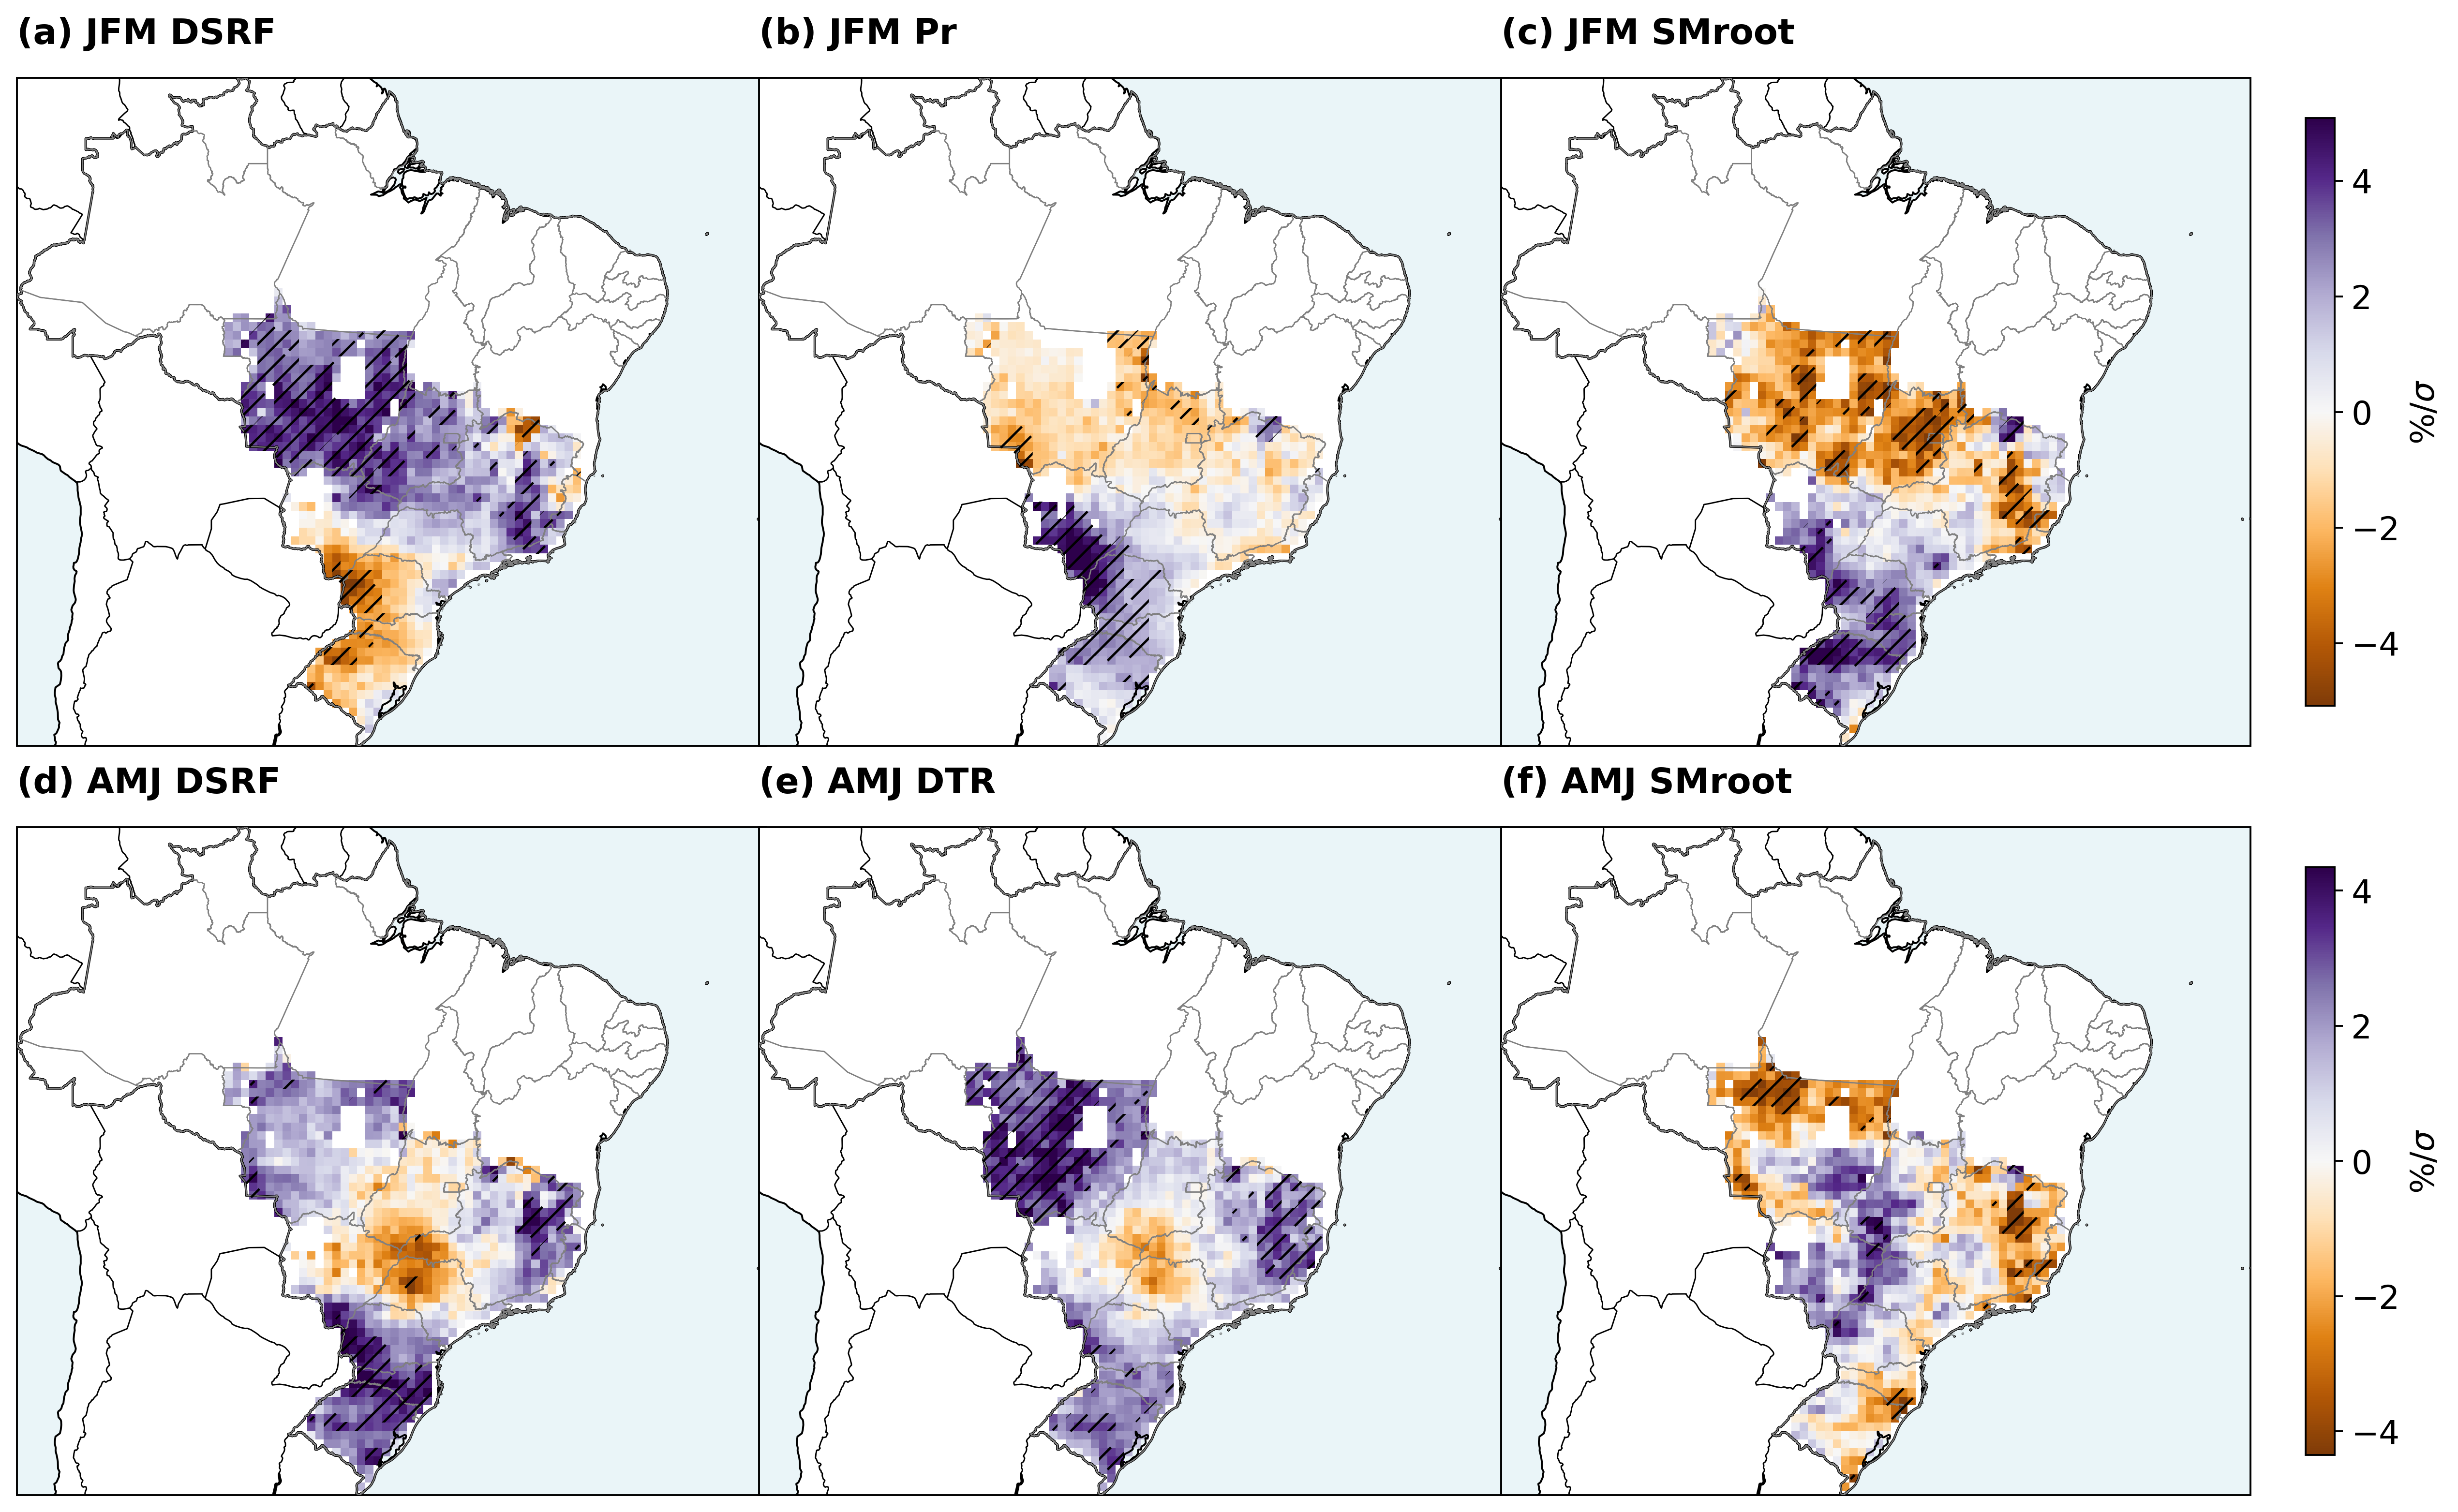

In [52]:
plot_ridge_2x3_panels_row_cb(
    betaJ=ds_JFM['beta'],
    betaA=ds_AMJ['beta'],
    sigJ=(ds_JFM['pv'] < 0.1),
    sigA=(ds_AMJ['pv'] < 0.1),
    vars_JFM=vars_JFM,
    vars_AMJ=vars_AMJ,
    BRA_shp=BRA_shp,
    Brazil_states=Brazil,
    cmap="PuOr",
    cbar_label=r'$\%/\sigma$',
    savepath="Figure3_2x3_JFM_AMJ.png"
)